In [1]:
from matplotlib import pyplot as plt
from pathlib import Path
import numpy as np

# Image Grid

In [2]:
directory_uninfected = Path("/projects/compures/datasets/NLM/crops/uninfected")
directory_parasitized = Path("/projects/compures/datasets/NLM/crops/parasitized")

In [3]:
random_uninfected = np.random.choice(list(directory_uninfected.glob("*.png")), 200)
random_parasitized = np.random.choice(list(directory_parasitized.glob("*.png")), 200)

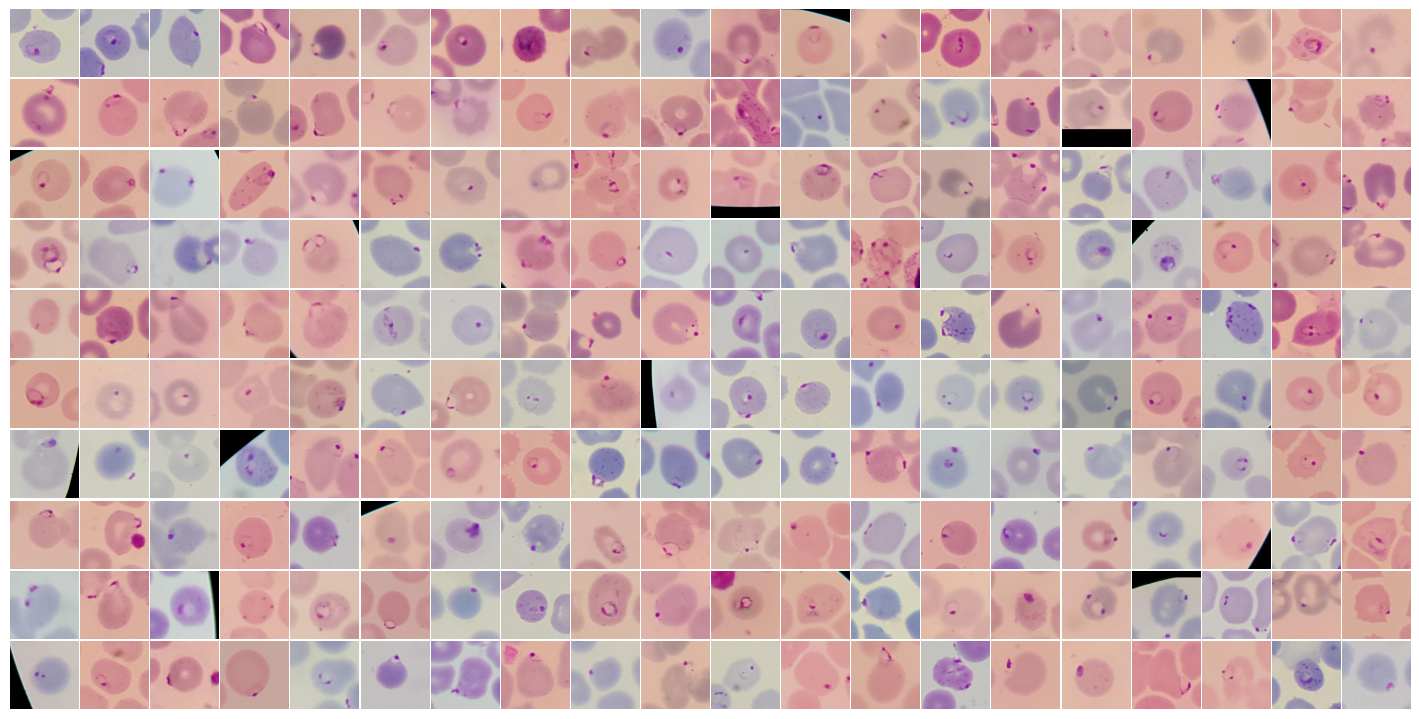

In [4]:
n_rows, n_cols = 10, 20
imgs = random_parasitized[: n_rows * n_cols]

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(n_cols * 0.7, n_rows * 0.7),  # important: width follows columns, height follows rows
)

for ax, img_path in zip(axes.flat, imgs):
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.axis("off")
for ax in axes.flat[len(imgs) :]:
    ax.axis("off")
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.03, hspace=0.03)

plt.show()

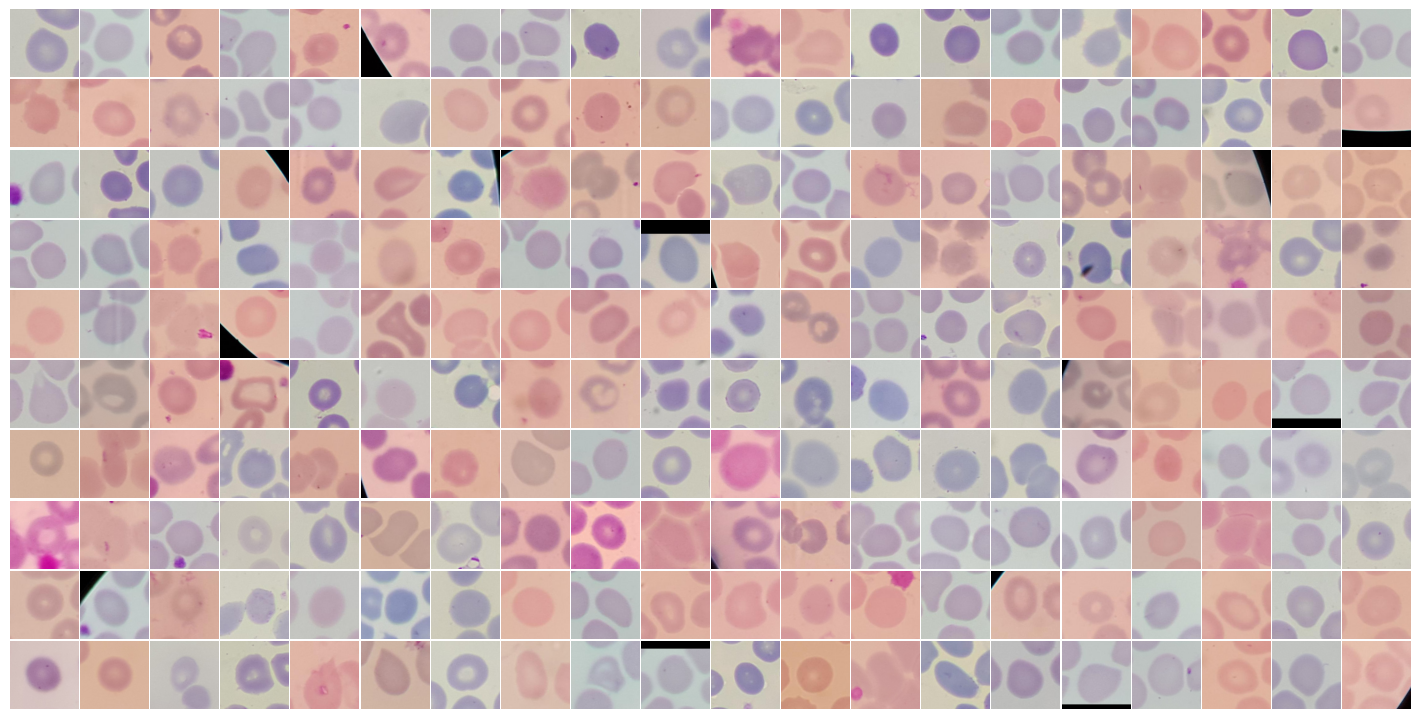

In [5]:
n_rows, n_cols = 10, 20
imgs = random_uninfected[: n_rows * n_cols]

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(n_cols * 0.7, n_rows * 0.7),  # important: width follows columns, height follows rows
)

for ax, img_path in zip(axes.flat, imgs):
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.axis("off")
for ax in axes.flat[len(imgs) :]:
    ax.axis("off")
plt.subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0.03, hspace=0.03)

plt.show()

# DINOv2 Embeddings

In [6]:
from pathlib import Path
from io import BytesIO

import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

CROP_ROOT = Path("/projects/compures/datasets/NLM/crops")
METADATA_PATH = CROP_ROOT / "metadata.csv"
EMBEDDINGS_DIR = Path("/projects/compures/nicolas/signal_sr/data/nlm")
EMBEDDING_PATHS = {
    "parasitized": EMBEDDINGS_DIR / "parasitized_embeddings.npz",
    "uninfected": EMBEDDINGS_DIR / "uninfected_embeddings.npz",
}

DINO_MODEL = "dinov2_vits14"
BATCH_SIZE = 256
NUM_WORKERS = 8
FORCE_RECOMPUTE = False
INTERACTIVE_UMAP_MAX_POINTS = 20_000
SEED = 0
DEVICE = "cuda:2" if torch.cuda.is_available() else "cpu"

metadata = pd.read_csv(METADATA_PATH).sort_values("crop_path").reset_index(drop=True)
metadata["crop_path"] = metadata["crop_path"].astype(str)
metadata.groupby("label_name").size()

label_name
parasitized      7952
uninfected     188711
dtype: int64

In [7]:
metadata

,crop_path,label,label_name,annotation_set,patient_id,image_name,cell_id,shape,center_x,center_y,source_image,source_gt
0,/projects/compures/datasets/NLM/crops/parasiti...,1,parasitized,point,143C39P4thinF_original,IMG_20150622_105102,1-1,Point,3833.300,306.600,/projects/compures/datasets/NLM/Point Set/143C...,/projects/compures/datasets/NLM/Point Set/143C...
1,/projects/compures/datasets/NLM/crops/parasiti...,1,parasitized,point,143C39P4thinF_original,IMG_20150622_105102,1-110,Point,3778.950,1189.350,/projects/compures/datasets/NLM/Point Set/143C...,/projects/compures/datasets/NLM/Point Set/143C...
2,/projects/compures/datasets/NLM/crops/parasiti...,1,parasitized,point,143C39P4thinF_original,IMG_20150622_105102,1-121,Point,3681.100,1169.800,/projects/compures/datasets/NLM/Point Set/143C...,/projects/compures/datasets/NLM/Point Set/143C...
3,/projects/compures/datasets/NLM/crops/parasiti...,1,parasitized,point,143C39P4thinF_original,IMG_20150622_105102,1-13,Point,3009.150,72.750,/projects/compures/datasets/NLM/Point Set/143C...,/projects/compures/datasets/NLM/Point Set/143C...
4,/projects/compures/datasets/NLM/crops/parasiti...,1,parasitized,point,143C39P4thinF_original,IMG_20150622_105102,1-132,Point,4250.200,1161.300,/projects/compures/datasets/NLM/Point Set/143C...,/projects/compures/datasets/NLM/Point Set/143C...
...,...,...,...,...,...,...,...,...,...,...,...,...
196658,/projects/compures/datasets/NLM/crops/uninfect...,0,uninfected,polygon,377C238NThinF,IMG_20151207_114653,5-95,Polygon,1873.950,1742.950,/projects/compures/datasets/NLM/Polygon Set/37...,/projects/compures/datasets/NLM/Polygon Set/37...
196659,/projects/compures/datasets/NLM/crops/uninfect...,0,uninfected,polygon,377C238NThinF,IMG_20151207_114653,5-96,Polygon,2007.525,1761.750,/projects/compures/datasets/NLM/Polygon Set/37...,/projects/compures/datasets/NLM/Polygon Set/37...
196660,/projects/compures/datasets/NLM/crops/uninfect...,0,uninfected,polygon,377C238NThinF,IMG_20151207_114653,5-97,Polygon,1731.700,1502.800,/projects/compures/datasets/NLM/Polygon Set/37...,/projects/compures/datasets/NLM/Polygon Set/37...
196661,/projects/compures/datasets/NLM/crops/uninfect...,0,uninfected,polygon,377C238NThinF,IMG_20151207_114653,5-98,Polygon,1720.650,1375.675,/projects/compures/datasets/NLM/Polygon Set/37...,/projects/compures/datasets/NLM/Polygon Set/37...


## Store DINOv2 Embeddings

In [8]:
preprocess = transforms.Compose(
    [
        transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ]
)


class CropDataset(Dataset):
    def __init__(self, df, transform):
        self.paths = df["crop_path"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        with Image.open(self.paths[idx]) as image:
            return self.transform(image.convert("RGB"))


def extract_embeddings(df, model):
    loader = DataLoader(
        CropDataset(df, preprocess),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda"),
    )
    chunks = []
    with torch.inference_mode():
        for batch in loader:
            batch = batch.to(DEVICE, non_blocking=True)
            features = model.forward_features(batch)["x_norm_clstoken"]
            chunks.append(features.cpu().numpy().astype(np.float32))
    return np.concatenate(chunks)


def metadata_arrays(df):
    arrays = {}
    for column in df.columns:
        values = df[column].to_numpy()
        if values.dtype == object:
            values = df[column].fillna("").astype(str).to_numpy(dtype=np.str_)
        arrays[column] = values
    return arrays


def save_embeddings(label_name, model):
    df = metadata[metadata["label_name"] == label_name].reset_index(drop=True)
    embeddings = extract_embeddings(df, model)
    np.savez_compressed(EMBEDDING_PATHS[label_name], embeddings=embeddings, **metadata_arrays(df))
    print(f"{label_name}: {embeddings.shape} -> {EMBEDDING_PATHS[label_name]}")


if FORCE_RECOMPUTE or not all(path.exists() for path in EMBEDDING_PATHS.values()):
    model = torch.hub.load("facebookresearch/dinov2", DINO_MODEL, trust_repo=True).to(DEVICE).eval()
    for label_name in ("parasitized", "uninfected"):
        save_embeddings(label_name, model)
else:
    print("Embedding files already exist. Set FORCE_RECOMPUTE = True to rebuild them.")

Embedding files already exist. Set FORCE_RECOMPUTE = True to rebuild them.


In [9]:
def load_embeddings(path):
    data = np.load(path)
    embeddings = data["embeddings"]
    df = pd.DataFrame({key: data[key] for key in data.files if key != "embeddings"})
    return embeddings, df


parasitized_embeddings, parasitized_df = load_embeddings(EMBEDDING_PATHS["parasitized"])
uninfected_embeddings, uninfected_df = load_embeddings(EMBEDDING_PATHS["uninfected"])

embeddings = np.vstack([parasitized_embeddings, uninfected_embeddings])
embedding_df = pd.concat([parasitized_df, uninfected_df], ignore_index=True)
embedding_df["label"] = embedding_df["label"].astype(int)
embeddings.shape, embedding_df.shape

((196663, 384), (196663, 12))

## PCA

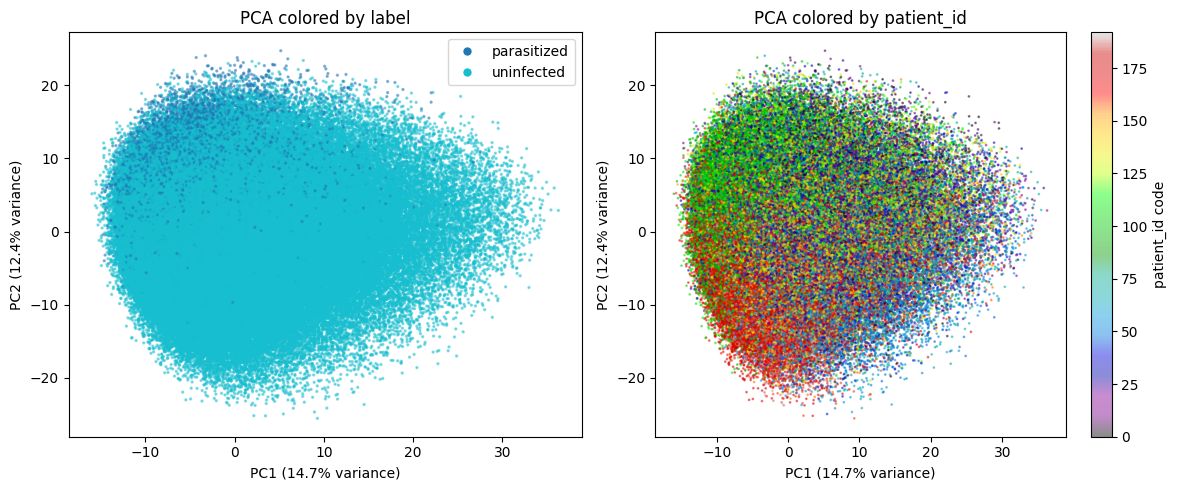

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd

pca = PCA(n_components=2, random_state=SEED)
pca_xy = pca.fit_transform(embeddings)

pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

pca_df = embedding_df.copy()
pca_df["PC1"] = pca_xy[:, 0]
pca_df["PC2"] = pca_xy[:, 1]

# Categorical codes
label_codes, label_names = pd.factorize(pca_df["label_name"])
patient_codes, _ = pd.factorize(pca_df["patient_id"])

pca_df["label_code"] = label_codes
pca_df["patient_code"] = patient_codes

# Randomize draw order to avoid artificial overlay
pca_plot = pca_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- PCA colored by label ----
n_labels = len(label_names)
label_cmap = plt.get_cmap("tab10", n_labels)

axes[0].scatter(pca_plot["PC1"], pca_plot["PC2"], c=pca_plot["label_code"], cmap=label_cmap, vmin=-0.5, vmax=n_labels - 0.5, s=2, alpha=0.45)

axes[0].set_title("PCA colored by label")
axes[0].set_xlabel(f"PC1 ({pc1_var:.1f}% variance)")
axes[0].set_ylabel(f"PC2 ({pc2_var:.1f}% variance)")

legend_handles = [
    Line2D([0], [0], marker="o", linestyle="", label=str(label_name), markerfacecolor=label_cmap(i), markeredgecolor="none", markersize=6)
    for i, label_name in enumerate(label_names)
]

axes[0].legend(handles=legend_handles, markerscale=1)

# ---- PCA colored by patient_id ----
scatter = axes[1].scatter(pca_plot["PC1"], pca_plot["PC2"], c=pca_plot["patient_code"], cmap="nipy_spectral", s=1, alpha=0.45)
axes[1].set_title("PCA colored by patient_id")
axes[1].set_xlabel(f"PC1 ({pc1_var:.1f}% variance)")
axes[1].set_ylabel(f"PC2 ({pc2_var:.1f}% variance)")

fig.colorbar(scatter, ax=axes[1], label="patient_id code")

plt.tight_layout()
plt.show()

## UMAP

In [ ]:
import umap

umap_xy = umap.UMAP(n_components=2, metric="cosine", random_state=SEED, verbose=True).fit_transform(embeddings)
umap_df = embedding_df.copy()
umap_df["UMAP1"] = umap_xy[:, 0]
umap_df["UMAP2"] = umap_xy[:, 1]

patient_codes, _ = pd.factorize(umap_df["patient_id"])
labels, _ = pd.factorize(umap_df["label_name"])

/projects/compures/nicolas/signal_sr/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(angular_rp_forest=True, metric='cosine', n_jobs=1, random_state=0, verbose=True)
Thu Jun 18 18:07:36 2026 Construct fuzzy simplicial set
Thu Jun 18 18:07:36 2026 Finding Nearest Neighbors
Thu Jun 18 18:07:36 2026 Building RP forest with 27 trees
Thu Jun 18 18:07:55 2026 NN descent for 18 iterations
	 1  /  18
	 2  /  18
	 3  /  18
	 4  /  18
	Stopping threshold met -- exiting after 4 iterations
Thu Jun 18 18:08:37 2026 Finished Nearest Neighbor Search
Thu Jun 18 18:08:43 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs


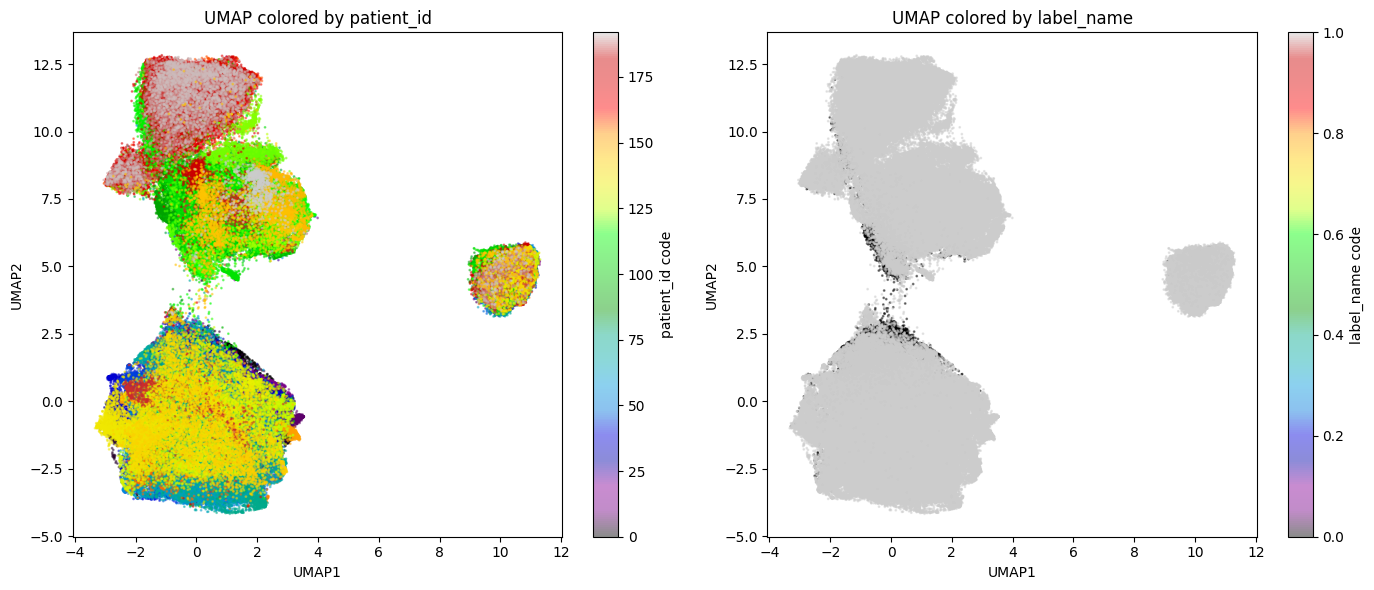

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter = axes[0].scatter(umap_df["UMAP1"], umap_df["UMAP2"], c=patient_codes, cmap="nipy_spectral", s=1, alpha=0.45)
plt.colorbar(scatter, label="patient_id code")
axes[0].set_title("UMAP colored by patient_id")
axes[0].set_xlabel("UMAP1")
axes[0].set_ylabel("UMAP2")

scatter = axes[1].scatter(umap_df["UMAP1"], umap_df["UMAP2"], c=labels, cmap="nipy_spectral", s=1, alpha=0.45)
plt.colorbar(scatter, label="label_name code")
axes[1].set_title("UMAP colored by label_name")
axes[1].set_xlabel("UMAP1")
axes[1].set_ylabel("UMAP2")

plt.tight_layout()
plt.show()

## Clustering

In [ ]:
from sklearn.cluster import KMeans

CLUSTER_OUTPUT_PATH = EMBEDDINGS_DIR / "dinov2_background_clusters.csv"

kmeans = KMeans(n_clusters=3, random_state=SEED, n_init="auto")
umap_df["background_cluster"] = kmeans.fit_predict(umap_df[["UMAP1", "UMAP2"]])

centroids = umap_df.groupby("background_cluster")[["UMAP1", "UMAP2"]].mean()
cropped_cluster = centroids["UMAP1"].idxmax()
left_clusters = centroids.drop(index=cropped_cluster)
blue_cluster = left_clusters["UMAP2"].idxmax()
red_cluster = left_clusters["UMAP2"].idxmin()

CLUSTER_TO_BACKGROUND = {
    blue_cluster: "blue_background",
    red_cluster: "red_background",
    cropped_cluster: "cropped_background",
}

umap_df["background_label"] = umap_df["background_cluster"].map(CLUSTER_TO_BACKGROUND)
umap_df["background_label"].value_counts()

background_label
red_background        92717
blue_background       87125
cropped_background    16821
Name: count, dtype: int64

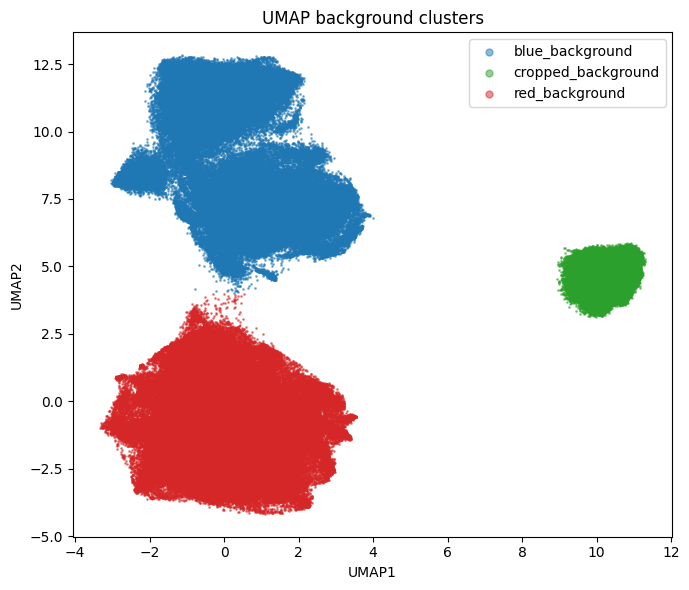

In [ ]:
BACKGROUND_COLORS = {
    "blue_background": "tab:blue",
    "red_background": "tab:red",
    "cropped_background": "tab:green",
}

plt.figure(figsize=(7, 6))
for background_label, part in umap_df.groupby("background_label"):
    plt.scatter(
        part["UMAP1"],
        part["UMAP2"],
        s=1,
        alpha=0.5,
        color=BACKGROUND_COLORS[background_label],
        label=background_label,
    )

plt.legend(markerscale=5)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP background clusters")
plt.tight_layout()
plt.show()

In [ ]:
umap_df.to_csv(CLUSTER_OUTPUT_PATH, index=False)
CLUSTER_OUTPUT_PATH

PosixPath('/projects/compures/nicolas/signal_sr/data/nlm/dinov2_background_clusters.csv')

## Interactive UMAP

In [ ]:
import ipywidgets as widgets
import plotly.graph_objects as go
from IPython.display import display

interactive_df = umap_df.sample(min(INTERACTIVE_UMAP_MAX_POINTS, len(umap_df)), random_state=SEED).reset_index(drop=True)
interactive_patient_codes, _ = pd.factorize(interactive_df["label_name"])
customdata = interactive_df[["crop_path", "label_name", "patient_id", "image_name", "cell_id"]].astype(str).to_numpy()

fig = go.FigureWidget(
    [
        go.Scattergl(
            x=interactive_df["UMAP1"],
            y=interactive_df["UMAP2"],
            mode="markers",
            marker={
                "color": interactive_patient_codes,
                "colorscale": "bluered",
                "size": 4,
                "opacity": 0.75,
                "showscale": True,
                "colorbar": {"title": "label_name code"},
            },
            customdata=customdata,
            hovertemplate=(
                "label_name: %{customdata[2]}<br>label: %{customdata[1]}<br>image: %{customdata[3]}<br>cell_id: %{customdata[4]}<extra></extra>"
            ),
        )
    ]
)
fig.update_layout(title="Interactive UMAP colored by label_name", xaxis_title="UMAP1", yaxis_title="UMAP2", height=650)

preview = widgets.Image(format="png", width=180, height=180)
caption = widgets.HTML("Hover over a point to preview its crop.")
paths = interactive_df["crop_path"].to_numpy()


def show_preview(trace, points, state):
    if not points.point_inds:
        return
    idx = points.point_inds[0]
    with Image.open(paths[idx]) as image:
        image = image.convert("RGB")
        image.thumbnail((180, 180))
        buffer = BytesIO()
        image.save(buffer, format="PNG")
    row = interactive_df.iloc[idx]
    preview.value = buffer.getvalue()
    caption.value = f"<b>{row.patient_id}</b><br>{row.label_name}<br>{Path(row.crop_path).name}"


fig.data[0].on_hover(show_preview)
display(widgets.HBox([fig, widgets.VBox([preview, caption])]))

    'data': [{'customdata': array([['/projects/compures/datasets/NLM/crops/uninf…